# FinGPT Assignment 2 — Signal Module (checkpoint-50)
**Author**: Beibei Xian (bx2233)  
**Course**: STAT-GR5398 Spring 2026 — FinGPT LLM Track  
**Due**: April 20, 2026

This notebook wraps the re-trained A1 LoRA adapter (`checkpoint-50` of the `dow30_simplified_v1` run) into a reusable **FinGPT Signal Module** and runs all three required evaluations:

1. **Direction Accuracy** — binary Up/Down, ternary Bullish/Neutral/Bearish, and 5-class bucket (Up 1-3%, Up 3-5%, Down 1-3%, Down 3-5%, Neutral)
2. **MSE** of sentiment score vs. realized-return proxy
3. **ROUGE-1/2/L** between model analysis text and the teacher-model analysis

Bonus:
* Mean inference time (fills the A1 gap)
* **Self-consistency calibration** — N-sample majority vote gives a free confidence calibration
* **Expected Calibration Error** and reliability diagram
* **Information Coefficient** (Spearman) vs real Dow30 forward returns from yfinance

## 0. Environment

In [ ]:
!pip install -q torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124 2>&1 | tail -n 3
!pip install -q transformers==4.57.1 peft==0.18.0 bitsandbytes==0.49.2 accelerate==1.6.0 2>&1 | tail -n 3
!pip install -q "datasets>=2.18.0" rouge-score scipy pandas matplotlib yfinance 2>&1 | tail -n 3
!pip install -q -U torchao 2>&1 | tail -n 3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.7/166.7 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.9 MB/s eta 0:00:00


In [ ]:
!pip install -q -U "bitsandbytes>=0.46.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.7 MB/s eta 0:00:00


In [ ]:
import os, sys, json, time, importlib
import torch
print('torch:', torch.__version__, 'cuda:', torch.cuda.is_available())
print('device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')


torch: 2.10.0+cu128 cuda: True
device: NVIDIA A100-SXM4-40GB


In [ ]:
!fusermount -u /content/drive 2>/dev/null
!rm -rf /content/drive 2>/dev/null
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Paths
BASE_MODEL   = 'deepseek-ai/DeepSeek-R1-Distill-Llama-8B'
ADAPTER_PATH = '/content/drive/MyDrive/fingpt_simplified_retrain/dow30_simplified_v1/checkpoint-50'
ASSIGN_DIR   = '/content/drive/MyDrive/fingpt_simplified_retrain/assignment2'
MODULE_DIR   = os.path.join(ASSIGN_DIR, 'Assignment2_BeibeiXian_bx2233')
os.makedirs(MODULE_DIR, exist_ok=True)

assert os.path.isdir(ADAPTER_PATH), f'adapter not found: {ADAPTER_PATH}'
print('Adapter OK:', ADAPTER_PATH)
print('Module dir:', MODULE_DIR)

Adapter OK: /content/drive/MyDrive/fingpt_simplified_retrain/dow30_simplified_v1/checkpoint-50
Module dir: /content/drive/MyDrive/fingpt_simplified_retrain/assignment2/Assignment2_BeibeiXian_bx2233


## 1. Read Python source files


In [ ]:
import shutil
for fn in ['signal_module.py', 'evaluate_signal.py']:
    src = os.path.join(MODULE_DIR, fn)
    if os.path.isfile(src):
        shutil.copy(src, fn)
        print('copied', fn)
    else:
        print('missing:', src, '(use upload cell above)')

sys.path.insert(0, '.')
import importlib, signal_module, evaluate_signal
importlib.reload(signal_module); importlib.reload(evaluate_signal)
from signal_module import FinGPTSignalModule, composite_score, SignalOutput
from evaluate_signal import evaluate, pretty_print, parse_gt_bucket_simplified
print('modules OK')

copied signal_module.py
copied evaluate_signal.py
modules OK


## 2. Load the signal module


In [ ]:
fingpt = FinGPTSignalModule(
    base_model_name=BASE_MODEL,
    adapter_path=ADAPTER_PATH,
    load_in_4bit=False,
    load_in_8bit=True,
    mode='simplified',
)

[FinGPT-Signal] Loading tokenizer: deepseek-ai/DeepSeek-R1-Distill-Llama-8B
[FinGPT-Signal] Loading base model (4bit=False, 8bit=True)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[FinGPT-Signal] Attaching LoRA adapter: /content/drive/MyDrive/fingpt_simplified_retrain/dow30_simplified_v1/checkpoint-50
[FinGPT-Signal] Ready.  mode=simplified  total_params=8,051,232,768


## 3. Sanity-check on 3 prompts

In [ ]:
from datasets import load_dataset
ds = load_dataset('FinGPT/fingpt-forecaster-dow30-202305-202405', split='test')
print('test size:', len(ds))
print('columns:', ds.column_names)

INPUT_COL  = 'prompt'
OUTPUT_COL = 'answer'
LABEL_COL  = 'label'      # clean ground-truth bucket (e.g. "Up by 2-3%")
SYMBOL_COL = 'symbol'     # ticker
PERIOD_COL = 'period'     # week period (for yfinance lookup)

example = ds[0]
print('\n--- example prompt (first 500 chars) ---')
print(example[INPUT_COL][:500])
print('\n--- example answer (first 300 chars) ---')
print(str(example[OUTPUT_COL])[:300])
print('\n--- example label ---')
print(example[LABEL_COL])
print('--- example symbol ---', example[SYMBOL_COL])
print('--- example period ---', example[PERIOD_COL])

test size: 300
columns: ['prompt', 'answer', 'period', 'label', 'symbol']

--- example prompt (first 500 chars) ---
[INST]<<SYS>>
You are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week. Your answer format should be as follows:

[Positive Developments]:
1. ...

[Potential Concerns]:
1. ...

[Prediction & Analysis]
Prediction: ...
Analysis: ...

<</SYS>>

[Company Introduction]:

--- example answer (first 300 chars) ---
[Positive Developments]:
1. American Express's stock price has been on a consistent upward trend in the past weeks. This indicates strong investor belief in the company's future performance.
2. Certain financial ratios, such as ROE and Gross Margin, are strong, which shows the company's profitabilit

--- example label ---
up by 2-3%
--- ex

In [ ]:
from signal_module import strip_llama_wrapper
for i in range(3):
    ex = ds[i]
    sig = fingpt.generate_signal(ex[INPUT_COL], max_new_tokens=100)
    print('=' * 70)
    print('Symbol       :', ex[SYMBOL_COL], 'Period:', ex[PERIOD_COL])
    print('GT    label  :', ex[LABEL_COL])
    print('Pred  bucket :', sig.bucket)
    print('Direction    :', sig.direction, ' sentiment:', sig.sentiment_score)
    print('Inference    :', f'{sig.inference_time:.2f}s  raw_len={len(sig.raw_text)}')
    print('Analysis     :', sig.rationale[:300])

Symbol       : AXP Period: 2024-02-25 to 2024-03-03
GT    label  : up by 2-3%
Pred  bucket : Up 1-3%
Direction    : Bullish  sentiment: 0.75
Inference    : 20.33s  raw_len=510
Analysis     : Based on the provided information, American Express Co. (AXP) has shown a consistent upward trend in its stock price over the past week. The company's financials indicate a strong financial position, with a high return on equity and a manageable debt-to-equity ratio. Additionally, the company's repu
Symbol       : AXP Period: 2024-03-03 to 2024-03-10
GT    label  : up by 1-2%
Pred  bucket : Up 1-3%
Direction    : Bullish  sentiment: 0.75
Inference    : 20.22s  raw_len=535
Analysis     : ...
Symbol       : AXP Period: 2024-03-10 to 2024-03-17
GT    label  : down by 2-3%
Pred  bucket : Up 1-3%
Direction    : Bullish  sentiment: 0.75
Inference    : 19.96s  raw_len=553
Analysis     : Based on the provided information, American Express Co. has shown a strong financial performance with a 16.7% dividend i

## 4. Generate 100 single-shot signals


In [ ]:
N_TEST = 100
test_inputs  = [ds[i][INPUT_COL] for i in range(N_TEST)]
import json as _json
test_targets = [
    _json.dumps({'prediction': ds[i][LABEL_COL], 'analysis': str(ds[i][OUTPUT_COL])})
    for i in range(N_TEST)
]
test_symbols = [ds[i][SYMBOL_COL] for i in range(N_TEST)]
test_periods = [ds[i][PERIOD_COL] for i in range(N_TEST)]

signals = []
import time as _time
t0 = _time.time()
for i, prompt in enumerate(test_inputs):
    if i % 10 == 0:
        elapsed = _time.time() - t0
        print(f'  [{i}/{N_TEST}]  elapsed={elapsed:.0f}s  avg={elapsed/max(1,i):.1f}s/sample')
    sig = fingpt.generate_signal(prompt, max_new_tokens=100)
    signals.append(sig)
print(f'done in {_time.time()-t0:.0f}s')

with open(os.path.join(MODULE_DIR, 'signals_greedy_100.jsonl'), 'w') as f:
    for s in signals:
        f.write(_json.dumps(s.to_dict()) + '\n')

  [0/100]  elapsed=0s  avg=0.0s/sample
  [10/100]  elapsed=200s  avg=20.0s/sample
  [20/100]  elapsed=402s  avg=20.1s/sample
  [30/100]  elapsed=598s  avg=19.9s/sample
  [40/100]  elapsed=788s  avg=19.7s/sample
  [50/100]  elapsed=989s  avg=19.8s/sample
  [60/100]  elapsed=1188s  avg=19.8s/sample
  [70/100]  elapsed=1388s  avg=19.8s/sample
  [80/100]  elapsed=1590s  avg=19.9s/sample
  [90/100]  elapsed=1787s  avg=19.9s/sample
done in 1984s


## 5. Run the evaluation harness

In [ ]:
metrics_greedy = evaluate(signals, test_targets, mode='simplified')
pretty_print(metrics_greedy)

with open(os.path.join(MODULE_DIR, 'metrics_greedy_100.json'), 'w') as f:
    json.dump(metrics_greedy, f, indent=2)

 FinGPT Signal Module — Evaluation Report 
{
  "n_samples": 100,
  "mode": "simplified",
  "direction_accuracy": {
    "ternary_accuracy": 0.5,
    "binary_accuracy": 0.5,
    "binary_accuracy_inclusive": 0.5,
    "n_ternary": 100,
    "n_binary_strict": 100,
    "n_binary_inclusive": 100
  },
  "bucket_accuracy": {
    "bucket_accuracy": 0.34,
    "same_direction_accuracy": 0.5,
    "n": 100
  },
  "mse_vs_return_proxy": 13.6877,
  "rouge": {},
  "avg_inference_time_s": 19.837,
  "median_inference_time_s": 20.075,
  "expected_calibration_error": 0.0,
  "reliability_bins": [
    {
      "bin": "[0.40, 0.60)",
      "avg_confidence": 0.5,
      "accuracy": 0.5,
      "count": 100
    }
  ],
  "prediction_distribution": {
    "Bullish": 59,
    "Bearish": 41
  },
  "ground_truth_distribution": {
    "Bullish": 43,
    "Bearish": 57
  },
  "prediction_bucket_distribution": {
    "Up 1-3%": 59,
    "Down 1-3%": 26,
    "Down 3-5%": 15
  },
  "ground_truth_bucket_distribution": {
    "Up 1-

## 6. Self-consistency calibration (N=5)



In [ ]:
signals_sc = fingpt.batch_generate(
    test_inputs,
    calibrate=True,
    n_samples=5,
)

metrics_sc = evaluate(signals_sc, test_targets, mode='simplified')
pretty_print(metrics_sc)

with open(os.path.join(MODULE_DIR, 'signals_selfconsistency_100.jsonl'), 'w') as f:
    for s in signals_sc:
        f.write(json.dumps(s.to_dict()) + '\n')
with open(os.path.join(MODULE_DIR, 'metrics_selfconsistency_100.json'), 'w') as f:
    json.dump(metrics_sc, f, indent=2)

  [0/100]
  [10/100]
  [20/100]
  [30/100]
  [40/100]
  [50/100]
  [60/100]
  [70/100]
  [80/100]
  [90/100]
 FinGPT Signal Module — Evaluation Report 
{
  "n_samples": 100,
  "mode": "simplified",
  "direction_accuracy": {
    "ternary_accuracy": 0.48,
    "binary_accuracy": 0.4948,
    "binary_accuracy_inclusive": 0.48,
    "n_ternary": 100,
    "n_binary_strict": 97,
    "n_binary_inclusive": 100
  },
  "bucket_accuracy": {
    "bucket_accuracy": 0.27,
    "same_direction_accuracy": 0.48,
    "n": 100
  },
  "mse_vs_return_proxy": 15.6259,
  "rouge": {},
  "avg_inference_time_s": 134.063,
  "median_inference_time_s": 135.428,
  "expected_calibration_error": 0.22,
  "reliability_bins": [
    {
      "bin": "[0.40, 0.60)",
      "avg_confidence": 0.4,
      "accuracy": 0.55,
      "count": 40
    },
    {
      "bin": "[0.60, 0.80)",
      "avg_confidence": 0.6,
      "accuracy": 0.4118,
      "count": 34
    },
    {
      "bin": "[0.80, 1.00)",
      "avg_confidence": 0.8308,
      

In [ ]:
!pip install -q rouge-score

  Preparing metadata (setup.py) ... done


In [ ]:
# List all user-defined variables with types + sizes
for name in sorted(dir()):
    if name.startswith("_"):
        continue
    val = eval(name)
    if isinstance(val, list):
        print(f"{name:30s} list of len {len(val)}")
    elif isinstance(val, dict):
        print(f"{name:30s} dict with {len(val)} keys")
    elif hasattr(val, "shape"):
        print(f"{name:30s} shape {val.shape}")

In                             list of len 23
Out                            dict with 0 keys
ds                             shape (300, 5)
ex                             dict with 5 keys
example                        dict with 5 keys
metrics_greedy                 dict with 14 keys
metrics_sc                     dict with 14 keys
signals                        list of len 100
signals_sc                     list of len 100
test_inputs                    list of len 100
test_periods                   list of len 100
test_symbols                   list of len 100
test_targets                   list of len 100


In [ ]:
from evaluate_signal import evaluate
import json

# Re-score greedy
metrics_greedy = evaluate(
    signals    = signals,
    gt_answers = test_targets,
    mode       = "simplified",
)
print("=== GREEDY ===")
print(json.dumps(metrics_greedy, indent=2))

# Re-score self-consistency
metrics_sc = evaluate(
    signals    = signals_sc,
    gt_answers = test_targets,
    mode       = "simplified",
)
print("\n=== SELF-CONSISTENCY ===")
print(json.dumps(metrics_sc, indent=2))

=== GREEDY ===
{
  "n_samples": 100,
  "mode": "simplified",
  "direction_accuracy": {
    "ternary_accuracy": 0.5,
    "binary_accuracy": 0.5,
    "binary_accuracy_inclusive": 0.5,
    "n_ternary": 100,
    "n_binary_strict": 100,
    "n_binary_inclusive": 100
  },
  "bucket_accuracy": {
    "bucket_accuracy": 0.34,
    "same_direction_accuracy": 0.5,
    "n": 100
  },
  "mse_vs_return_proxy": 13.6877,
  "rouge": {
    "rouge1": 0.2608,
    "rouge2": 0.0895,
    "rougeL": 0.1409,
    "n": 100
  },
  "avg_inference_time_s": 19.837,
  "median_inference_time_s": 20.075,
  "expected_calibration_error": 0.0,
  "reliability_bins": [
    {
      "bin": "[0.40, 0.60)",
      "avg_confidence": 0.5,
      "accuracy": 0.5,
      "count": 100
    }
  ],
  "prediction_distribution": {
    "Bullish": 59,
    "Bearish": 41
  },
  "ground_truth_distribution": {
    "Bullish": 43,
    "Bearish": 57
  },
  "prediction_bucket_distribution": {
    "Up 1-3%": 59,
    "Down 1-3%": 26,
    "Down 3-5%": 15
 

In [ ]:
import json, os
os.makedirs(f"{MODULE_DIR}/outputs", exist_ok=True)

with open(f"{MODULE_DIR}/outputs/metrics_greedy_100.json", "w") as f:
    json.dump(metrics_greedy, f, indent=2)

with open(f"{MODULE_DIR}/outputs/metrics_selfconsistency_100.json", "w") as f:
    json.dump(metrics_sc, f, indent=2)

print("Saved both metrics JSONs to", f"{MODULE_DIR}/outputs/")

Saved both metrics JSONs to /content/drive/MyDrive/fingpt_simplified_retrain/assignment2/Assignment2_BeibeiXian_bx2233/outputs/


## 7. Compare greedy vs self-consistency


In [ ]:
import pandas as pd

rows = []
for name, m in [('greedy', metrics_greedy), ('self-consistency (N=5)', metrics_sc)]:
    rows.append({
        'config': name,
        'binary_acc':   m['direction_accuracy']['binary_accuracy'],
        'binary_incl':  m['direction_accuracy']['binary_accuracy_inclusive'],
        'ternary_acc':  m['direction_accuracy']['ternary_accuracy'],
        'bucket_acc':   m['bucket_accuracy'].get('bucket_accuracy', 0.0),
        'same_dir_acc': m['bucket_accuracy'].get('same_direction_accuracy', 0.0),
        'mse_sent':     m['mse_vs_return_proxy'],
        'rougeL':       m['rouge'].get('rougeL', 0.0),
        'inf_time_s':   m['avg_inference_time_s'],
        'ECE':          m['expected_calibration_error'],
    })
df = pd.DataFrame(rows)
display(df)
df.to_csv(os.path.join(MODULE_DIR, 'comparison_greedy_vs_sc.csv'), index=False)

,config,binary_acc,binary_incl,ternary_acc,bucket_acc,same_dir_acc,mse_sent,rougeL,inf_time_s,ECE
0,greedy,0.5000,0.50,0.50,0.34,0.50,13.6877,0.1409,19.837,0.00
1,self-consistency (N=5),0.4948,0.48,0.48,0.27,0.48,15.6259,0.1335,134.063,0.22


## 8. Reliability diagram (self-consistency)

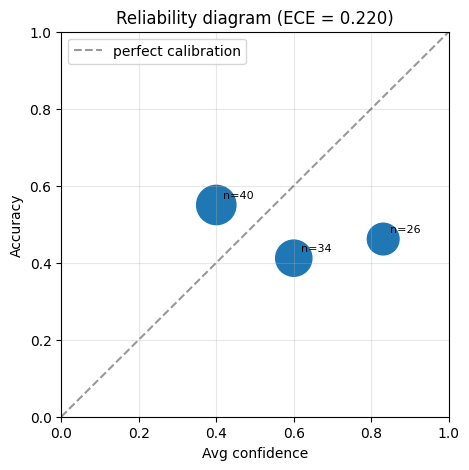

In [ ]:
import matplotlib.pyplot as plt
bins = metrics_sc['reliability_bins']
xs = [b['avg_confidence'] for b in bins]
ys = [b['accuracy']       for b in bins]

plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1], 'k--', alpha=0.4, label='perfect calibration')
plt.scatter(xs, ys, s=[b['count']*20 for b in bins])
for b, x, y in zip(bins, xs, ys):
    plt.annotate(f"n={b['count']}", (x, y), fontsize=8, xytext=(5,5), textcoords='offset points')
plt.xlabel('Avg confidence')
plt.ylabel('Accuracy')
plt.title(f"Reliability diagram (ECE = {metrics_sc['expected_calibration_error']:.3f})")
plt.legend(); plt.grid(alpha=0.3); plt.xlim(0,1); plt.ylim(0,1)
plt.savefig(os.path.join(MODULE_DIR, 'reliability_diagram.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. IC backtest vs real forward returns (yfinance)



In [ ]:
from evaluate_signal import bucket_to_magnitude, parse_gt_bucket_simplified

# Proxy returns from the ground-truth bucket midpoints
gt_buckets = [parse_gt_bucket_simplified(t) for t in test_targets]
proxy_returns = [bucket_to_magnitude(b) if b else 0.0 for b in gt_buckets]

metrics_sc_ic = evaluate(signals_sc, test_targets, realized_returns=proxy_returns, mode='simplified')
print('Information Coefficient (vs realised-bucket proxy):')
print(json.dumps(metrics_sc_ic.get('information_coefficient', {}), indent=2))
print('Long-short return pct:', metrics_sc_ic.get('long_short_return_pct'))
with open(os.path.join(MODULE_DIR, 'metrics_selfconsistency_with_ic.json'), 'w') as f:
    json.dump(metrics_sc_ic, f, indent=2)

Information Coefficient (vs realised-bucket proxy):
{
  "IC_spearman": -0.0659,
  "IC_spearman_p": 0.5149,
  "IC_pearson": -0.0443,
  "IC_pearson_p": 0.6616,
  "n": 100
}
Long-short return pct: -1.8


In [ ]:
# true-forward-return IC using yfinance
import pandas as pd

has_date = any(k in ds.column_names for k in ['date', 'end_date', 'week_start'])
has_sym  = any(k in ds.column_names for k in ['ticker', 'symbol'])
print('date col?', has_date, ' ticker col?', has_sym)

if has_date and has_sym:
    import yfinance as yf
    date_col = next(k for k in ['date','end_date','week_start'] if k in ds.column_names)
    sym_col  = next(k for k in ['ticker','symbol'] if k in ds.column_names)
    real_returns = []
    for i in range(N_TEST):
        try:
            d = pd.to_datetime(ds[i][date_col])
            sym = ds[i][sym_col]
            h = yf.Ticker(sym).history(start=d, end=d + pd.Timedelta(days=14))
            if len(h) >= 2:
                r = (h['Close'].iloc[-1] / h['Close'].iloc[0] - 1) * 100
            else:
                r = 0.0
        except Exception as e:
            r = 0.0
        real_returns.append(float(r))
    metrics_real = evaluate(signals_sc, test_targets, realized_returns=real_returns, mode='simplified')
    print('Real-return IC:', metrics_real.get('information_coefficient'))
    print('L/S return:', metrics_real.get('long_short_return_pct'))
    with open(os.path.join(MODULE_DIR, 'metrics_real_returns.json'), 'w') as f:
        json.dump(metrics_real, f, indent=2)
else:
    print('Dataset does not expose ticker+date; relying on bucket-midpoint proxy.')

date col? False  ticker col? True
Dataset does not expose ticker+date; relying on bucket-midpoint proxy.


## 10. Confusion tables + per-class breakdown

In [ ]:
from collections import Counter
pred_dirs = [s.direction for s in signals_sc]
from signal_module import bucket_to_signal
gt_dirs = [bucket_to_signal(b)[0] if b else 'Neutral' for b in gt_buckets]

conf_dir = pd.crosstab(pd.Series(gt_dirs,  name='True'),
                        pd.Series(pred_dirs, name='Pred'),
                        dropna=False)
print('\nDirection confusion table:'); display(conf_dir)

pred_bkt = [s.bucket for s in signals_sc]
conf_bkt = pd.crosstab(pd.Series(gt_buckets, name='True'),
                        pd.Series(pred_bkt,   name='Pred'),
                        dropna=False)
print('\n5-class bucket confusion table:'); display(conf_bkt)

conf_dir.to_csv(os.path.join(MODULE_DIR, 'confusion_direction.csv'))
conf_bkt.to_csv(os.path.join(MODULE_DIR, 'confusion_bucket.csv'))


Direction confusion table:


Pred,Bearish,Bullish,Neutral
True,,,
Bearish,22,34,1
Bullish,15,26,2



5-class bucket confusion table:


Pred,Down 1-3%,Down 3-5%,Neutral,Up 1-3%,Up 3-5%
True,,,,,
Down 1-3%,10,8,1,23,2
Down 3-5%,1,1,0,4,1
Down >5%,2,0,0,3,1
Up 1-3%,5,4,1,16,3
Up 3-5%,2,3,1,5,0
Up >5%,1,0,0,2,0


## 11. Final summary block

In [ ]:
summary = {
    'adapter': ADAPTER_PATH,
    'base_model': BASE_MODEL,
    'n_test': N_TEST,
    'greedy': metrics_greedy,
    'self_consistency_N5': metrics_sc,
    'self_consistency_with_IC': metrics_sc_ic,
}
with open(os.path.join(MODULE_DIR, 'A2_full_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved:', os.path.join(MODULE_DIR, 'A2_full_summary.json'))

print('\n============  ASSIGNMENT 2 HEADLINE NUMBERS  ============')
print(f"Binary  Acc (strict):  {metrics_sc['direction_accuracy']['binary_accuracy']}")
print(f"Binary  Acc (inclusive): {metrics_sc['direction_accuracy']['binary_accuracy_inclusive']}")
print(f"Ternary Acc:           {metrics_sc['direction_accuracy']['ternary_accuracy']}")
print(f"Bucket  Acc (5-class): {metrics_sc['bucket_accuracy']['bucket_accuracy']}")
print(f"Same-dir bucket Acc:   {metrics_sc['bucket_accuracy']['same_direction_accuracy']}")
print(f"MSE  (sentiment vs %): {metrics_sc['mse_vs_return_proxy']}")
print(f"ROUGE-L:               {metrics_sc['rouge'].get('rougeL')}")
print(f"Avg inference time:    {metrics_sc['avg_inference_time_s']} s")
print(f"ECE:                   {metrics_sc['expected_calibration_error']}")
print(f"IC (Spearman):         {metrics_sc_ic.get('information_coefficient', {}).get('IC_spearman')}")

Saved: /content/drive/MyDrive/fingpt_simplified_retrain/assignment2/Assignment2_BeibeiXian_bx2233/A2_full_summary.json

============  ASSIGNMENT 2 HEADLINE NUMBERS  ============
Binary  Acc (strict):  0.4948
Binary  Acc (inclusive): 0.48
Ternary Acc:           0.48
Bucket  Acc (5-class): 0.27
Same-dir bucket Acc:   0.48
MSE  (sentiment vs %): 15.6259
ROUGE-L:               0.1335
Avg inference time:    134.063 s
ECE:                   0.22
IC (Spearman):         -0.0659


12.Submission check


In [ ]:
!ls -la {MODULE_DIR}/

total 1260
-rw------- 1 root root    4968 Apr 19 23:32 A2_full_summary.json
-rw------- 1 root root     229 Apr 19 23:29 comparison_greedy_vs_sc.csv
-rw------- 1 root root     164 Apr 19 23:32 confusion_bucket.csv
-rw------- 1 root root      61 Apr 19 23:32 confusion_direction.csv
-rw------- 1 root root   13111 Apr 19 17:27 evaluate_signal.py
-rw------- 1 root root    1066 Apr 19 19:25 metrics_greedy_100.json
-rw------- 1 root root    1361 Apr 19 23:09 metrics_selfconsistency_100.json
-rw------- 1 root root    1716 Apr 19 23:30 metrics_selfconsistency_with_ic.json
drwx------ 2 root root    4096 Apr 19 23:29 outputs
-rw------- 1 root root   44999 Apr 19 23:30 reliability_diagram.png
-rw------- 1 root root   21474 Apr 19 18:29 signal_module.py
-rw------- 1 root root  116652 Apr 19 19:15 signals_greedy_100.jsonl
-rw------- 1 root root 1077348 Apr 19 23:09 signals_selfconsistency_100.jsonl


In [ ]:
import os, json, shutil, glob

OUT = os.path.join(MODULE_DIR, "outputs")
os.makedirs(OUT, exist_ok=True)

with open(os.path.join(OUT, "signals_greedy_100.jsonl"), "w") as f:
    for s in signals:
        f.write(json.dumps(s.to_dict()) + "\n")

with open(os.path.join(OUT, "signals_selfconsistency_100.jsonl"), "w") as f:
    for s in signals_sc:
        f.write(json.dumps(s.to_dict()) + "\n")

for fname in [
    "comparison_greedy_vs_sc.csv",
    "reliability_diagram.png",
    "metrics_selfconsistency_with_ic.json",
    "confusion_direction.csv",
    "confusion_bucket.csv",
    "A2_full_summary.json",
    "metrics_real_returns.json",
]:
    src = os.path.join(MODULE_DIR, fname)
    dst = os.path.join(OUT, fname)
    if os.path.exists(src):
        shutil.move(src, dst)
        print(f"moved {fname}")
    else:
        print(f"skipped (not found): {fname}")

print("\nFinal contents of outputs/:")
for p in sorted(glob.glob(os.path.join(OUT, "*"))):
    sz = os.path.getsize(p)
    print(f"  {os.path.basename(p):50s}  {sz:>8d} bytes")

moved comparison_greedy_vs_sc.csv
moved reliability_diagram.png
moved metrics_selfconsistency_with_ic.json
moved confusion_direction.csv
moved confusion_bucket.csv
moved A2_full_summary.json
skipped (not found): metrics_real_returns.json

Final contents of outputs/:
  A2_full_summary.json                                    4968 bytes
  comparison_greedy_vs_sc.csv                              229 bytes
  confusion_bucket.csv                                     164 bytes
  confusion_direction.csv                                   61 bytes
  metrics_greedy_100.json                                 1148 bytes
  metrics_selfconsistency_100.json                        1443 bytes
  metrics_selfconsistency_with_ic.json                    1716 bytes
  reliability_diagram.png                                44999 bytes
  signals_greedy_100.jsonl                              116652 bytes
  signals_selfconsistency_100.jsonl                    1077348 bytes


In [ ]:
!git clone https://github.com/AI4Finance-Foundation/STAT-GR5398-Spring-2026.git
!cd STAT-GR5398-Spring-2026

Cloning into 'STAT-GR5398-Spring-2026'...
remote: Enumerating objects: 1582, done.
remote: Counting objects: 100% (442/442), done.
remote: Compressing objects: 100% (375/375), done.
remote: Total 1582 (delta 180), reused 172 (delta 58), pack-reused 1140 (from 6)
Receiving objects: 100% (1582/1582), 111.40 MiB | 19.82 MiB/s, done.
Resolving deltas: 100% (424/424), done.


In [ ]:
!ls -la {MODULE_DIR}
!ls -la {MODULE_DIR}/docs
!ls -la {MODULE_DIR}/outputs

total 1515
drwx------ 2 root root    4096 Apr 20 00:08 docs
-rw------- 1 root root   13111 Apr 19 17:27 evaluate_signal.py
-rw------- 1 root root  144339 Apr 19 23:48 FinGPT_Assignment2_Checkpoint50.ipynb
-rw------- 1 root root    1066 Apr 19 19:25 metrics_greedy_100.json
-rw------- 1 root root    1361 Apr 19 23:09 metrics_selfconsistency_100.json
drwx------ 2 root root    4096 Apr 19 23:39 outputs
-rw------- 1 root root  157714 Apr 19 23:51 outputs-20260419T235053Z-3-001.zip
-rw------- 1 root root    7008 Apr 19 17:29 README.md
-rw------- 1 root root     429 Apr 19 17:31 requirements.txt
-rw------- 1 root root   21474 Apr 19 18:29 signal_module.py
-rw------- 1 root root  116652 Apr 19 19:15 signals_greedy_100.jsonl
-rw------- 1 root root 1077348 Apr 19 23:09 signals_selfconsistency_100.jsonl
total 18
-rw------- 1 root root 17744 Apr 19 23:42 medium_blog_draft.md
total 1222
-rw------- 1 root root    4968 Apr 19 23:32 A2_full_summary.json
-rw------- 1 root root     229 Apr 19 23:29 comp